# Airbnb Listings — Professional Data Analyst Project
### Python • NumPy • Pandas • SQL • Statistics • Matplotlib • Seaborn • Sentiment Analysis


# Project Roadmap

Professional workflow: data preparation → exploratory analysis → SQL business questions → statistics → sentiment analysis → dashboard data → business insights.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 2. Load Dataset


In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df.head()

Saving compressed_data_extracted.csv to compressed_data_extracted.csv


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


## 3. Dataset Overview


In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.columns.tolist())

Rows: 102599
Columns: 26
['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']


## 4. Data Types


In [4]:
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum().values,
    "unique": [df[c].nunique(dropna=True) for c in df.columns]
}))

,column,dtype,missing,unique
id,id,int64,0,102058
NAME,NAME,object,250,61281
host id,host id,int64,0,102057
host_identity_verified,host_identity_verified,object,289,2
host name,host name,object,406,13190
neighbourhood group,neighbourhood group,object,29,7
neighbourhood,neighbourhood,object,16,224
lat,lat,float64,8,21991
long,long,float64,8,17774
country,country,object,532,1


## 5. Data Quality Audit


In [5]:
print("Duplicate rows:", df.duplicated().sum())
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

Duplicate rows: 541


,missing_count
license,102597
house_rules,52131
last review,15893
reviews per month,15879
country,532
availability 365,448
minimum nights,409
host name,406
review rate number,326
calculated host listings count,319


## 6. Numeric Cleaning


In [6]:
for c in ["price", "service fee"]:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")
display(df[["price","service fee"]].describe())

,price,service fee
count,102352.000000,102326.000000
mean,625.293536,125.026924
std,331.671614,66.325739
min,50.000000,10.000000
25%,340.000000,68.000000
50%,624.000000,125.000000
75%,913.000000,183.000000
max,1200.000000,240.000000


## 7. Date Cleaning


In [7]:
df["last review"] = pd.to_datetime(df["last review"], errors="coerce")
df["review_year"] = df["last review"].dt.year
df["review_month"] = df["last review"].dt.month
display(df[["last review","review_year","review_month"]].head())

,last review,review_year,review_month
0,2021-10-19,2021.0,10.0
1,2022-05-21,2022.0,5.0
2,NaT,NaN,NaN
3,2019-07-05,2019.0,7.0
4,2018-11-19,2018.0,11.0


## 8. Categorical Cleaning


In [8]:
cat_cols = ["room type","neighbourhood group","host_identity_verified","instant_bookable","cancellation_policy"]
for c in cat_cols:
    df[c] = df[c].astype("string").str.strip()
display(df[cat_cols].head())

,room type,neighbourhood group,host_identity_verified,instant_bookable,cancellation_policy
0,Private room,Brooklyn,unconfirmed,False,strict
1,Entire home/apt,Manhattan,verified,False,moderate
2,Private room,Manhattan,<NA>,True,flexible
3,Entire home/apt,Brooklyn,unconfirmed,True,moderate
4,Entire home/apt,Manhattan,verified,False,moderate


## 9. Feature Engineering


In [9]:
df["price_per_min_night"] = df["price"] / df["minimum nights"].replace(0, np.nan)
df["availability_band"] = pd.cut(df["availability 365"], [-1,90,180,270,365],
                                 labels=["Low","Medium","High","Very High"])
df["review_activity_band"] = pd.cut(df["number of reviews"], [-1,5,25,100,np.inf],
                                    labels=["Very Low","Low","Medium","High"])
display(df[["price","minimum nights","price_per_min_night","availability_band"]].head())

,price,minimum nights,price_per_min_night,availability_band
0,966.0,10.0,96.600000,Very High
1,142.0,30.0,4.733333,High
2,620.0,3.0,206.666667,Very High
3,368.0,30.0,12.266667,Very High
4,204.0,10.0,20.400000,Very High


## 10. Descriptive Statistics


In [10]:
numeric_cols = ["price","service fee","minimum nights","number of reviews",
                "reviews per month","review rate number",
                "calculated host listings count","availability 365"]
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
price,102352.0,625.293536,331.671614,50.00,340.00,624.00,913.0,1200.0
service fee,102326.0,125.026924,66.325739,10.00,68.00,125.00,183.0,240.0
minimum nights,102190.0,8.135845,30.553781,-1223.00,2.00,3.00,5.0,5645.0
number of reviews,102416.0,27.483743,49.508954,0.00,1.00,7.00,30.0,1024.0
reviews per month,86720.0,1.374022,1.746621,0.01,0.22,0.74,2.0,90.0
review rate number,102273.0,3.279106,1.284657,1.00,2.00,3.00,4.0,5.0
calculated host listings count,102280.0,7.936605,32.218780,1.00,1.00,1.00,2.0,332.0
availability 365,102151.0,141.133254,135.435024,-10.00,3.00,96.00,269.0,3677.0


## 11. Room Type Analysis


,listings,median_price,avg_price,median_reviews,avg_availability
room type,,,,,
Entire home/apt,53701,624.0,625.082232,8.0,142.760376
Private room,46556,623.0,625.007363,7.0,137.557126
Shared room,2226,651.0,634.132101,5.0,172.666214
Hotel room,116,644.5,668.465517,18.0,218.310345


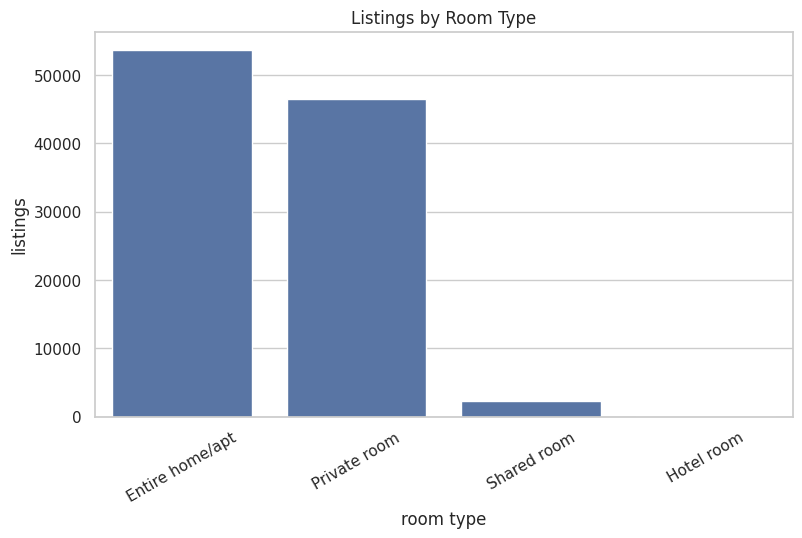

In [31]:
room_summary = df.groupby("room type").agg(
    listings=("id","count"),
    median_price=("price","median"),
    avg_price=("price","mean"),
    median_reviews=("number of reviews","median"),
    avg_availability=("availability 365","mean")
).sort_values("listings", ascending=False)
display(room_summary)

plt.figure(figsize=(9,5))
sns.barplot(data=room_summary.reset_index(), x="room type", y="listings")
plt.title("Listings by Room Type")
plt.xticks(rotation=30)
plt.show()

## 12. Neighborhood Analysis


,listings,median_price,avg_price,avg_reviews
neighbourhood group,,,,
Manhattan,43792,621.0,622.440227,24.120957
Brooklyn,41842,626.0,626.562193,28.511012
Queens,13267,628.0,630.207647,33.706985
Bronx,2712,633.0,627.766359,31.653392
Staten Island,955,628.0,624.490546,35.704712
brookln,1,580.0,580.000000,167.000000
manhatan,1,460.0,460.000000,260.000000


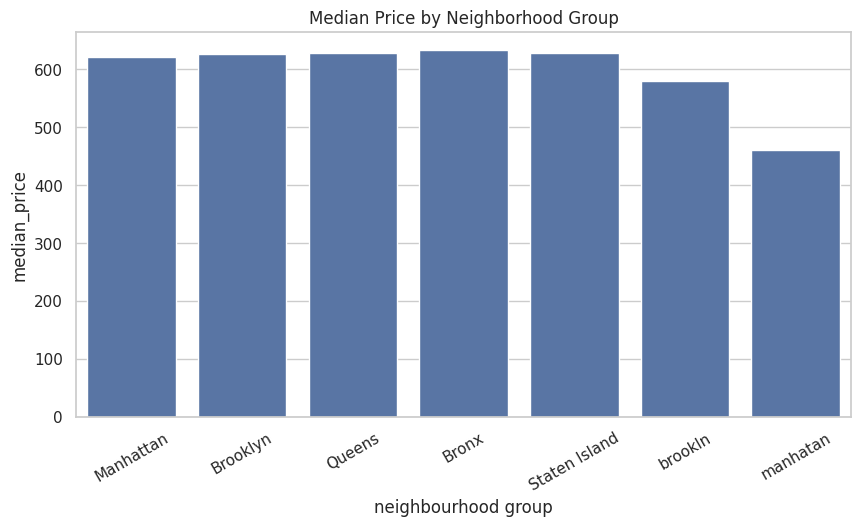

In [12]:
ng = df.groupby("neighbourhood group").agg(
    listings=("id","count"),
    median_price=("price","median"),
    avg_price=("price","mean"),
    avg_reviews=("number of reviews","mean")
).sort_values("listings", ascending=False)
display(ng)

plt.figure(figsize=(10,5))
sns.barplot(data=ng.reset_index(), x="neighbourhood group", y="median_price")
plt.title("Median Price by Neighborhood Group")
plt.xticks(rotation=30)
plt.show()

## 13. Host Analysis


,listings,median_price,avg_reviews
host_identity_verified,,,
unconfirmed,51200,626.0,27.541759
verified,51110,623.0,27.319199
<NA>,289,656.0,46.266436


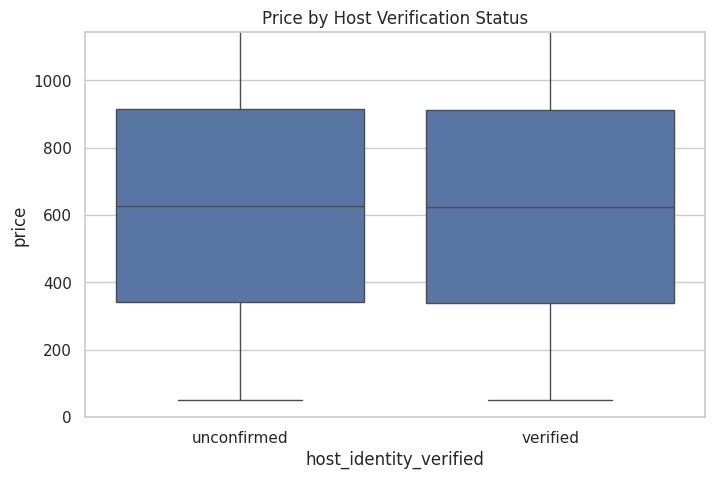

In [13]:
host_summary = df.groupby("host_identity_verified", dropna=False).agg(
    listings=("id","count"),
    median_price=("price","median"),
    avg_reviews=("number of reviews","mean")
)
display(host_summary)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="host_identity_verified", y="price")
plt.ylim(0, df["price"].quantile(.95))
plt.title("Price by Host Verification Status")
plt.show()

## 14. Review Analysis


,avg_reviews,median_reviews,avg_reviews_per_month
room type,,,
Hotel room,83.439655,18.0,2.844224
Private room,27.808926,7.0,1.433150
Entire home/apt,27.375881,8.0,1.318349
Shared room,20.380952,5.0,1.418054


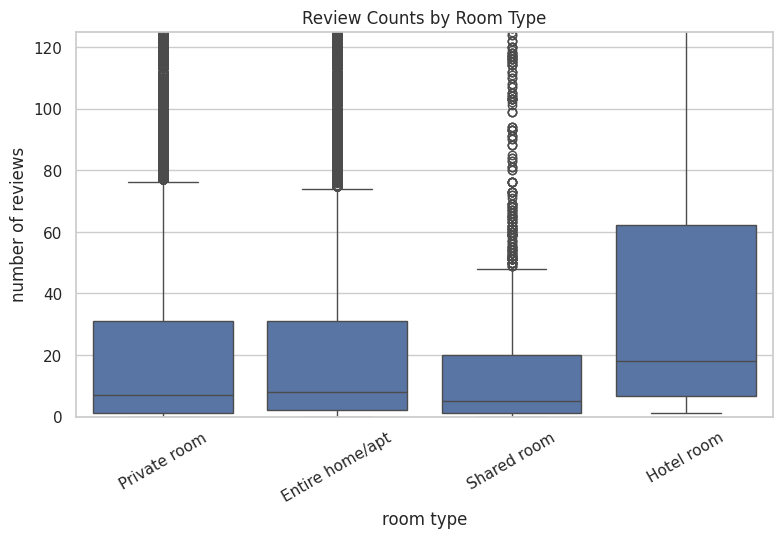

In [14]:
review_summary = df.groupby("room type").agg(
    avg_reviews=("number of reviews","mean"),
    median_reviews=("number of reviews","median"),
    avg_reviews_per_month=("reviews per month","mean")
).sort_values("avg_reviews", ascending=False)
display(review_summary)

plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="room type", y="number of reviews")
plt.ylim(0, df["number of reviews"].quantile(.95))
plt.title("Review Counts by Room Type")
plt.xticks(rotation=30)
plt.show()

## 15. Correlation Analysis


,price,minimum nights,number of reviews,reviews per month,review rate number,availability 365,calculated host listings count
price,1.000000,-0.003471,0.005229,0.004186,-0.004576,-0.002833,-0.000106
minimum nights,-0.003471,1.000000,-0.049997,-0.096141,-0.002167,0.063541,0.084846
number of reviews,0.005229,-0.049997,1.000000,0.590939,-0.018412,0.099368,-0.080907
reviews per month,0.004186,-0.096141,0.590939,1.000000,0.037526,0.077193,-0.025621
review rate number,-0.004576,-0.002167,-0.018412,0.037526,1.000000,-0.006217,0.024273
availability 365,-0.002833,0.063541,0.099368,0.077193,-0.006217,1.000000,0.159194
calculated host listings count,-0.000106,0.084846,-0.080907,-0.025621,0.024273,0.159194,1.000000


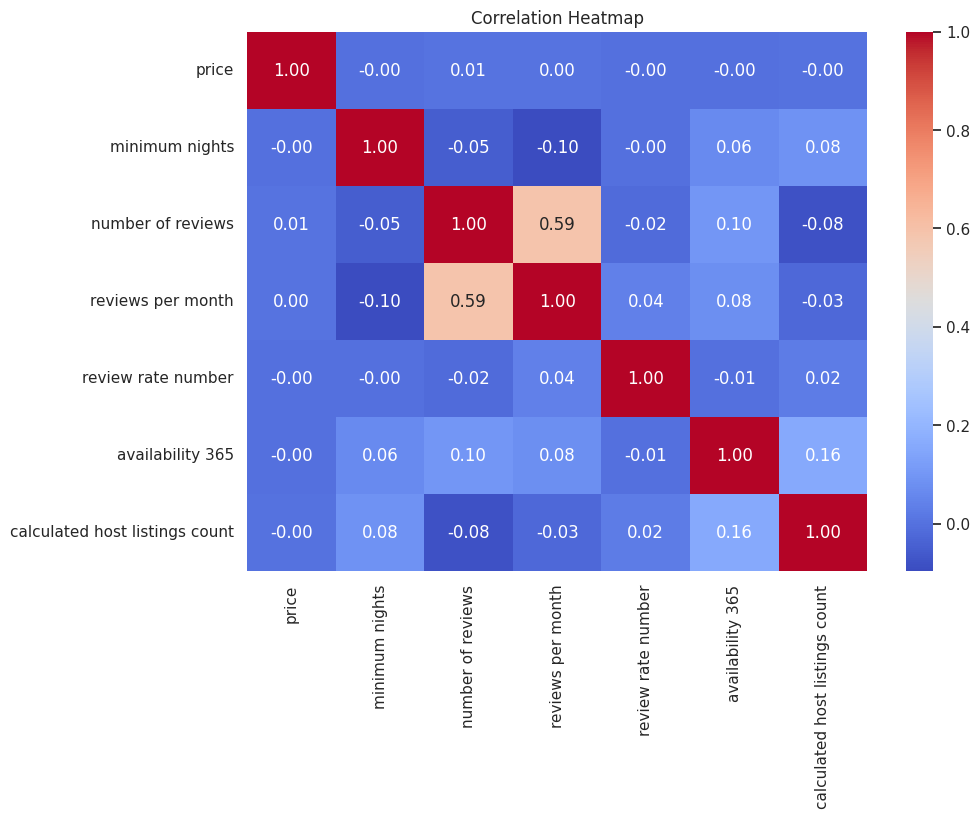

In [15]:
corr_cols = ["price","minimum nights","number of reviews","reviews per month",
             "review rate number","availability 365","calculated host listings count"]
corr = df[corr_cols].corr()
display(corr)
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 16. Outlier Analysis


In [16]:
q1, q3 = df["price"].quantile([.25,.75])
iqr = q3-q1
lower, upper = q1-1.5*iqr, q3+1.5*iqr
outliers = df[(df["price"] < lower) | (df["price"] > upper)]
print("Lower threshold:", lower)
print("Upper threshold:", upper)
print("Price outliers:", len(outliers))
display(outliers[["id","price","room type","neighbourhood group"]].head(10))

Lower threshold: -519.5
Upper threshold: 1772.5
Price outliers: 0


,id,price,room type,neighbourhood group


## 17. SQL Setup
Create the SQLite connection and load the cleaned Airbnb dataframe into an SQL table.


In [17]:
conn = sqlite3.connect(":memory:")
df.to_sql("airbnb", conn, index=False, if_exists="replace")
print("SQL table created:", "airbnb")


SQL table created: airbnb


## 18. SQL — Room Type Performance


In [18]:
query = '''
SELECT "room type" AS room_type,
       COUNT(*) AS listings,
       ROUND(AVG(price),2) AS avg_price,
       ROUND(AVG("number of reviews"),2) AS avg_reviews
FROM airbnb
GROUP BY "room type"
ORDER BY listings DESC;
'''
display(pd.read_sql_query(query, conn))

,room_type,listings,avg_price,avg_reviews
0,Entire home/apt,53701,625.08,27.38
1,Private room,46556,625.01,27.81
2,Shared room,2226,634.13,20.38
3,Hotel room,116,668.47,83.44


## 19. SQL — Room Type Ranking Within Neighborhood



In [19]:
query = '''
WITH x AS (
 SELECT "neighbourhood group" AS neighborhood_group,
        "room type" AS room_type,
        COUNT(*) AS listings,
        AVG(price) AS avg_price
 FROM airbnb
 GROUP BY "neighbourhood group", "room type"
)
SELECT *,
       RANK() OVER (
         PARTITION BY neighborhood_group
         ORDER BY listings DESC
       ) AS room_rank
FROM x
ORDER BY neighborhood_group, room_rank;
'''
display(pd.read_sql_query(query, conn))

,neighborhood_group,room_type,listings,avg_price,room_rank
0,None,Private room,18,639.222222,1
1,None,Entire home/apt,11,692.800000,2
2,Bronx,Private room,1573,634.710644,1
3,Bronx,Entire home/apt,1022,620.232581,2
4,Bronx,Shared room,117,600.256410,3
5,Brooklyn,Entire home/apt,20575,626.896406,1
6,Brooklyn,Private room,20434,625.870764,2
7,Brooklyn,Shared room,825,634.317073,3
8,Brooklyn,Hotel room,8,736.125000,4
9,Manhattan,Entire home/apt,26473,623.147570,1


## 20. SQL — Neighborhood Price Analysis


In [20]:
query2 = '''
SELECT "neighbourhood group" AS neighborhood_group,
       COUNT(*) AS listings,
       ROUND(AVG(price), 2) AS avg_price,
       MIN(price) AS min_price,
       MAX(price) AS max_price
FROM airbnb
GROUP BY "neighbourhood group"
ORDER BY avg_price DESC;
'''
display(pd.read_sql_query(query2, conn))


,neighborhood_group,listings,avg_price,min_price,max_price
0,None,29,658.36,54.0,1133.0
1,Queens,13267,630.21,50.0,1200.0
2,Bronx,2712,627.77,50.0,1200.0
3,Brooklyn,41842,626.56,50.0,1200.0
4,Staten Island,955,624.49,50.0,1200.0
5,Manhattan,43792,622.44,50.0,1200.0
6,brookln,1,580.00,580.0,580.0
7,manhatan,1,460.00,460.0,460.0


## 21. SQL — Top 10 Neighborhoods



In [21]:
query3 = '''
SELECT neighbourhood,
       COUNT(*) AS listings,
       ROUND(AVG(price), 2) AS avg_price
FROM airbnb
GROUP BY neighbourhood
ORDER BY listings DESC
LIMIT 10;
'''
display(pd.read_sql_query(query3, conn))


,neighbourhood,listings,avg_price
0,Bedford-Stuyvesant,7937,622.98
1,Williamsburg,7775,625.54
2,Harlem,5466,626.80
3,Bushwick,4982,633.34
4,Hell's Kitchen,3965,621.07
5,Upper West Side,3860,616.53
6,Upper East Side,3680,618.20
7,East Village,3492,617.50
8,Midtown,3390,609.55
9,Crown Heights,3262,617.53


## 22. SQL  — Instant Booking Comparison


In [22]:
query4 = '''
SELECT instant_bookable,
       COUNT(*) AS listings,
       ROUND(AVG(price), 2) AS avg_price,
       ROUND(AVG("number of reviews"), 2) AS avg_reviews,
       ROUND(AVG("availability 365"), 2) AS avg_availability
FROM airbnb
GROUP BY instant_bookable
ORDER BY listings DESC;
'''
display(pd.read_sql_query(query4, conn))


,instant_bookable,listings,avg_price,avg_reviews,avg_availability
0,False,51474,625.17,27.35,141.66
1,True,51020,625.40,27.52,140.50
2,None,105,633.83,74.18,195.44


## 23. SQL — Availability Segmentation



In [23]:
query5 = '''
SELECT
  CASE
    WHEN "availability 365" <= 90 THEN 'Low'
    WHEN "availability 365" <= 180 THEN 'Medium'
    WHEN "availability 365" <= 270 THEN 'High'
    ELSE 'Very High'
  END AS availability_band,
  COUNT(*) AS listings,
  ROUND(AVG(price), 2) AS avg_price,
  ROUND(AVG("number of reviews"), 2) AS avg_reviews
FROM airbnb
GROUP BY availability_band
ORDER BY
  CASE availability_band
    WHEN 'Low' THEN 1
    WHEN 'Medium' THEN 2
    WHEN 'High' THEN 3
    ELSE 4
  END;
'''
display(pd.read_sql_query(query5, conn))


,availability_band,listings,avg_price,avg_reviews
0,Low,49671,626.34,21.13
1,Medium,14974,625.63,35.56
2,High,11928,620.95,38.96
3,Very High,3662,612.77,35.96
4,Very High,22364,627.11,28.69


## 24.Sentiment Analysis — TextBlob



In [24]:
from textblob import TextBlob
df["text_for_sentiment"] = df["house_rules"].fillna("").astype(str).str.strip()
df["sentiment_score"] = df["text_for_sentiment"].apply(lambda x: TextBlob(x).sentiment.polarity if x else 0)
df["sentiment"] = df["sentiment_score"].apply(lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral"))
display(df[["house_rules","sentiment_score","sentiment"]].head(10))
display(df["sentiment"].value_counts().to_frame("count"))


,house_rules,sentiment_score,sentiment
0,Clean up and treat the home the way you'd like...,0.366667,Positive
1,Pet friendly but please confirm with me if the...,0.206818,Positive
2,"I encourage you to use my kitchen, cooking and...",-0.075000,Negative
3,NaN,0.000000,Neutral
4,"Please no smoking in the house, porch or on th...",0.100000,Positive
5,"No smoking, please, and no drugs.",0.000000,Neutral
6,Please no shoes in the house so bring slippers...,0.135714,Positive
7,House Guidelines for our BnB We are delighted ...,0.475000,Positive
8,- Please clean up after yourself when using th...,0.155556,Positive
9,NO SMOKING OR PETS ANYWHERE ON THE PROPERTY 1....,0.225000,Positive


,count
sentiment,
Neutral,65883
Positive,31709
Negative,5007


## 25. Sentiment Visualization



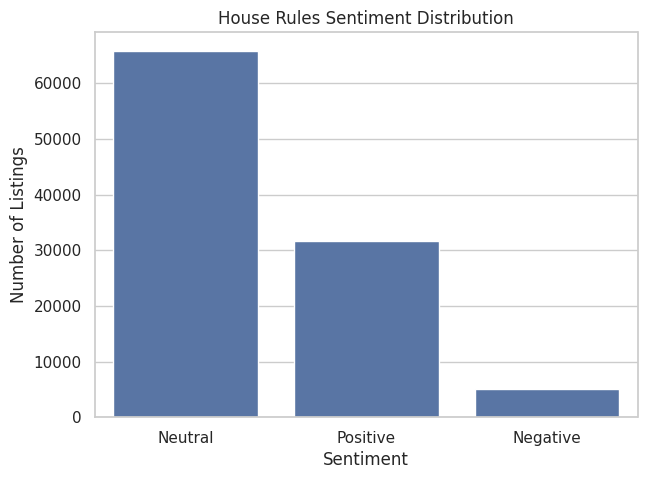

In [25]:
sentiment_counts = df["sentiment"].value_counts()
plt.figure(figsize=(7,5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("House Rules Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Listings")
plt.show()


## 26. Sentiment by Room Type



sentiment,Negative,Neutral,Positive
room type,,,
Entire home/apt,4.81,65.24,29.95
Hotel room,0.00,100.00,0.00
Private room,4.99,62.94,32.07
Shared room,4.45,64.20,31.36


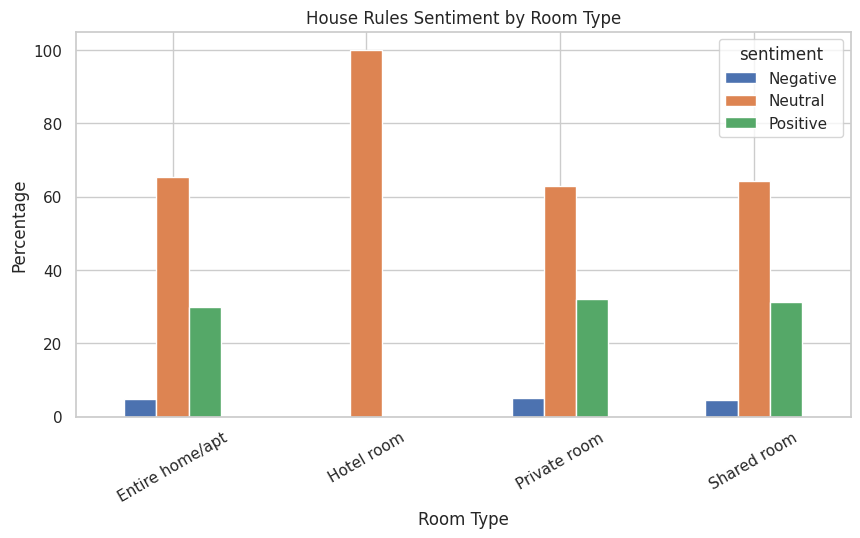

In [26]:
sentiment_room = pd.crosstab(df["room type"], df["sentiment"], normalize="index") * 100
display(sentiment_room.round(2))
sentiment_room.plot(kind="bar", figsize=(10,5))
plt.title("House Rules Sentiment by Room Type")
plt.ylabel("Percentage")
plt.xlabel("Room Type")
plt.xticks(rotation=30)
plt.show()


## 27. Dashboard Dataset


In [27]:
kpis = pd.Series({
    "Total Listings": len(df),
    "Median Price": df["price"].median(),
    "Average Price": df["price"].mean(),
    "Average Reviews": df["number of reviews"].mean(),
    "Average Availability": df["availability 365"].mean()
})
display(kpis)
top_neighborhoods = df.groupby("neighbourhood").agg(
    listings=("id","count"),
    median_price=("price","median")
).sort_values("listings", ascending=False).head(10)
display(top_neighborhoods)

,0
Total Listings,102599.000000
Median Price,624.000000
Average Price,625.293536
Average Reviews,27.483743
Average Availability,141.133254


,listings,median_price
neighbourhood,,
Bedford-Stuyvesant,7937,621.0
Williamsburg,7775,626.0
Harlem,5466,620.0
Bushwick,4982,640.0
Hell's Kitchen,3965,619.0
Upper West Side,3860,619.0
Upper East Side,3680,627.0
East Village,3492,615.5
Midtown,3390,609.0


## 28. Minimum Nights Analysis


,avg_minimum_nights,median_minimum_nights
room type,,
Entire home/apt,9.807671,3.0
Shared room,6.600540,1.0
Private room,6.291545,2.0
Hotel room,4.131579,1.0


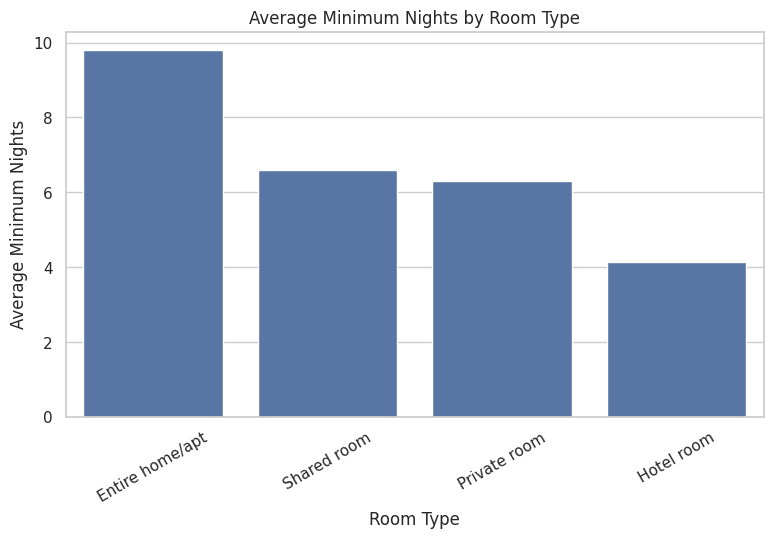

Insight: Higher minimum-night requirements can affect booking flexibility and customer accessibility.


In [28]:
min_night_summary = df.groupby("room type").agg(
    avg_minimum_nights=("minimum nights","mean"),
    median_minimum_nights=("minimum nights","median")
).sort_values("avg_minimum_nights", ascending=False)
display(min_night_summary)

plt.figure(figsize=(9,5))
sns.barplot(data=min_night_summary.reset_index(), x="room type", y="avg_minimum_nights")
plt.title("Average Minimum Nights by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Minimum Nights")
plt.xticks(rotation=30)
plt.show()

print("Insight: Higher minimum-night requirements can affect booking flexibility and customer accessibility.")

## 29. Key Insights


In [29]:
print("Top room type by listing count:", room_summary["listings"].idxmax())
print("Highest-listing neighborhood group:", ng["listings"].idxmax())
print("Median listing price:", round(df["price"].median(),2))
print("Average annual availability:", round(df["availability 365"].mean(),2))
print("Average reviews per listing:", round(df["number of reviews"].mean(),2))

Top room type by listing count: Entire home/apt
Highest-listing neighborhood group: Manhattan
Median listing price: 624.0
Average annual availability: 141.13
Average reviews per listing: 27.48


## 30. Final Export


In [30]:
# Cleaned data ko CSV file mein save karo
df.to_csv("Airbnb_cleaned.csv", index=False)

# CSV file download karo
from google.colab import files
files.download("Airbnb_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This project focuses on **Airbnb listing, pricing, room type, neighbourhood, review, availability, and host analysis**.

It answers questions such as:

1. Which **room type** has the most listings?
2. Which **room type** has the highest average price?
3. Which **neighbourhood group** has the most listings?
4. Which **neighbourhood group** has the highest average price?
5. How does **price vary across room types and neighbourhoods**?
6. Which room types have the **highest review activity and availability**?
7. Which listings and neighbourhoods have the **highest minimum-night requirements**?
8. How do **host verification and instant booking** vary across listings?
9. What relationships exist between **price, reviews, availability, and minimum nights**?
10. What **sentiment patterns** are found in Airbnb house rules?